Processing subject CC120049 (1/133)
Processing subject CC120065 (2/133)
Processing subject CC120218 (3/133)
Processing subject CC120470 (4/133)
Processing subject CC120640 (5/133)
Processing subject CC120795 (6/133)
Processing subject CC121428 (7/133)
Processing subject CC210023 (8/133)
Processing subject CC210088 (9/133)
Processing subject CC220107 (10/133)
Processing subject CC220335 (11/133)
Processing subject CC220419 (12/133)
Processing subject CC220518 (13/133)
Processing subject CC220519 (14/133)
Processing subject CC220828 (15/133)
Processing subject CC220974 (16/133)
Processing subject CC221002 (17/133)
Processing subject CC221487 (18/133)
Processing subject CC221585 (19/133)
Processing subject CC221977 (20/133)
Processing subject CC222258 (21/133)
Processing subject CC222264 (22/133)
Processing subject CC222496 (23/133)
Processing subject CC222652 (24/133)
Processing subject CC223286 (25/133)
Processing subject CC310051 (26/133)
Processing subject CC310086 (27/133)
Processing

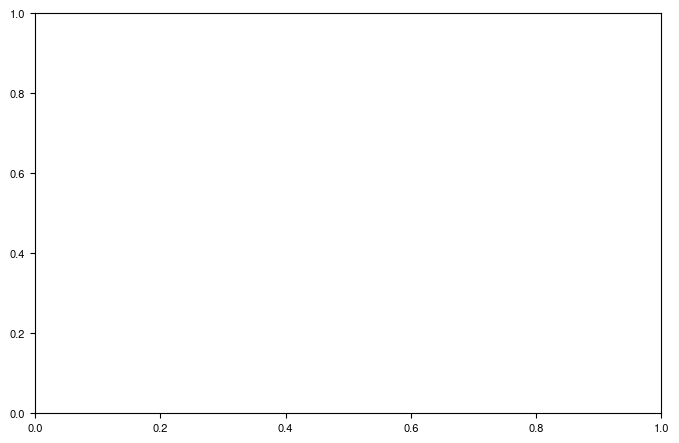

In [ ]:
"""
Thi script generates the source data for Supplementary Figure 08, which shows the empty-room power spectral density (PSD) for the two phases of the study. It loads the PSDs for each subject and phase, averages them across subjects, and plots the mean PSD with shaded error bars representing the standard error of the mean (SEM) of the phases differences across subjects. The source data is saved in a TSV file.
"""

from specparam.utils.spectral import interpolate_spectra
import pandas as pd
import numpy as np
import mne
import os

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

maindir = ''

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

lfreq = 0.1 #Hz
hfreq = 145.0 #Hz
fsample = 300.0 #Hz
frange = f"{round(lfreq, 1)}-{int(hfreq)}Hz"

trans = True # Whether to use head transformation or not
zmm = 44 # destination z coordinate head position in mm

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

fitting_param = 'finley'
psd_deriv_folder = f'mne-bids-pipeline_erm_filt{frange}_fs{int(fsample)}Hz'
megtype = 'grad'

# ---- File with subjects and arms ----
subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
subjects = subjectsdf.index.tolist()

# Wheter to plot the PSDs in absolute units or normalized by total power (relative units)
normalize_psd = False # Set to True to attenuate the power differences due to system change
snorm = '_normalized' if normalize_psd else ''


def load_subject_emptyroom_spectrum(id, armx, phase):
    # --- Define the psd directory and file ---
    bids_project_folder = f'BIDS_long_{phase}_{task}_arm{armx}'
    psd_derivdir = os.path.join(maindir, bids_project_folder,
            'derivatives', psd_deriv_folder)
    psd_megdir = os.path.join(psd_derivdir, 'sub-'+id, 'meg')

    #'sub-CC120049_task-noise_proc-sss_desc-dur50sepo2sWL_psd.hdf5'

    psdfilename = f'sub-{id}_task-noise_proc-filt_desc-dur50sepo2sWL_psd.hdf5'
    psdfile = os.path.join(psd_megdir, psdfilename)

    # --- Read the power spectrum data ---
    psd = mne.time_frequency.read_spectrum(psdfile)

    # --- Get the psds for each epoch and channel ---
    spectra, freqs = psd.pick(megtype).get_data(return_freqs=True)
        
    if normalize_psd:
        chan_units = '(normalized, a.u.)'
    else:
        chan_units = psd.units()[megtype]
    del psd # free memory

    # limit to 1-40 Hz
    freq_mask = (freqs >= 1) & (freqs <= 40)
    freqs = freqs[freq_mask]
    spectra = spectra[:, :, freq_mask]
    
    # --- Average PSD across epochs ---
    spectra = np.average(spectra, axis=0)

    # ---- Interpolate 23.4 Hz (Golan's) noise ----            
    freqs, spectra = interpolate_spectra(freqs, spectra, [21.9, 23.9]) # channels x frequencies

    # --- Average PSD across channels ---
    spectra = np.average(spectra, axis=0)  # average across channels

    if normalize_psd:
        spectra = spectra / np.trapezoid(spectra, freqs)  # normalize PSD by total power

    return spectra, freqs, chan_units


phases_spectra = [None, None] # This will store the spectrum sum for each phase to then divide by the number of subjects and obtain the mean spectrum per phase, for the dA effect plot

spectra_diff = [] # This will store the difference between phases for each subject, to then compute the SEM of the difference for the error bars in the dA effect plot

n=0
# loop over subjects
for id in subjects: # just do one subject for now to test
    print(f'Processing subject {id} ({n+1}/{len(subjects)})')
    armx = subjectsdf.loc[id,'arm']
    n += 1
    
    subj_spectra = []
    # Loop over phases
    for p, phase in enumerate(phases):                    
        # Load the total spectrum for this subject and phase
        spectrum, freqs, chan_units = load_subject_emptyroom_spectrum(id, armx, phase)
        
        phases_spectra[p] = spectrum if phases_spectra[p] is None else phases_spectra[p] + spectrum
        subj_spectra.append(spectrum)
        
    # end loop over phases
        
    spectra_diff.append(subj_spectra[1] - subj_spectra[0]) # save the difference between phases for this subject, to then compute the SEM of the difference for the error bars in the dA effect plot
    del subj_spectra # free memory

phases_spectra = [s / n for s in phases_spectra] # compute the mean spectrum for each phase by dividing the sum by the number of subjects

spectra_sem = np.array(spectra_diff).std(axis=0) / np.sqrt(len(subjects)) # compute the SEM of the difference between phases across subjects, to be used as error bars in the dA effect plot

data_dict = {
    'freqs': freqs,
    'phase_2_spectrum': phases_spectra[0],
    'phase_5_spectrum': phases_spectra[1],
    'spectra_sem': spectra_sem,
    'chan_units': chan_units
}

data_df = pd.DataFrame(data_dict)
data_outfile = os.path.join(datadir, f'supp_figure08_source_data.tsv')
data_df.to_csv(data_outfile, sep='\t', index=False)
print(f"Saved source data to: {data_outfile}")